In [1]:
import pandas as pd

In [ ]:
df= pd.read_csv("/content/Nassau Candy Distributor.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
df.shape

(10194, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['calc_check'] = df['Sales'] - df["Cost"] - df['Gross Profit']
df['calc_check'].abs().max()

7.105427357601002e-15

In [ ]:
(df[['Sales', 'Units', 'Gross Profit', 'Cost']] < 0).sum()

,0
Sales,0
Units,0
Gross Profit,0
Cost,0


In [ ]:
df['Product Name'].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper',
       'Fizzy Lifting Drinks', 'Laffy Taffy', 'SweeTARTS', 'Nerds',
       'Hair Toffee', 'Everlasting Gobstopper', 'Fun Dip'], dtype=object)

In [ ]:
df['Product Name'] = df['Product Name'].str.replace(
    'Wonka Bar -Scrumdiddlyumptious',
    'Wonka Bar - Scrumdiddlyumptious'
)
df['Product Name'].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar - Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper',
       'Fizzy Lifting Drinks', 'Laffy Taffy', 'SweeTARTS', 'Nerds',
       'Hair Toffee', 'Everlasting Gobstopper', 'Fun Dip'], dtype=object)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [ ]:
df = df.drop(columns=['calc_check'])
df.shape

(10194, 18)

In [ ]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']
df[['Product Name', 'Sales', 'Gross Profit', 'Gross Margin %', 'Profit per Unit']].head()

,Product Name,Sales,Gross Profit,Gross Margin %,Profit per Unit
0,Wonka Bar - Milk Chocolate,6.50,4.22,64.923077,2.11
1,Wonka Bar - Triple Dazzle Caramel,7.50,4.90,65.333333,2.45
2,Wonka Bar - Nutty Crunch Surprise,10.47,7.47,71.346705,2.49
3,Wonka Bar - Scrumdiddlyumptious,10.80,7.50,69.444444,2.50
4,Wonka Bar - Triple Dazzle Caramel,11.25,7.35,65.333333,2.45


In [4]:
product_summary = df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum'),
    Avg_Margin=('Gross Margin %', 'mean'),
    Total_Units=('Units', 'sum')
).reset_index()

product_summary = product_summary.sort_values('Total_Profit', ascending=False)
product_summary

,Product Name,Total_Sales,Total_Profit,Avg_Margin,Total_Units
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,69.444444,7743
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,7596
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,8267
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,6755
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,6914
6,Lickable Wallpaper,7860.00,3930.00,50.000000,393
14,Wonka Gum,597.50,310.70,52.000000,478
0,Everlasting Gobstopper,130.00,104.00,80.000000,13
4,Kazookles,1205.75,92.75,7.692308,371
3,Hair Toffee,76.50,59.50,77.777778,17


In [5]:
# Overall averages తీసుకుందాం, threshold గా వాడడానికి
avg_margin = product_summary['Avg_Margin'].mean()
avg_sales = product_summary['Total_Sales'].mean()

print("Average Margin:", avg_margin)
print("Average Sales:", avg_sales)

# Ippudu prathi product ni classify cheyyi
def classify(row):
    if row['Total_Sales'] >= avg_sales and row['Avg_Margin'] < avg_margin:
        return 'High-Sales, Low-Margin (Risk)'
    elif row['Total_Sales'] >= avg_sales and row['Avg_Margin'] >= avg_margin:
        return 'High-Sales, High-Margin (Star)'
    elif row['Total_Sales'] < avg_sales and row['Avg_Margin'] < avg_margin:
        return 'Low-Sales, Low-Margin (Weak)'
    else:
        return 'Low-Sales, High-Margin (Niche)'

product_summary['Category'] = product_summary.apply(classify, axis=1)
product_summary

Average Margin: 57.388613522063004
Average Sales: 9452.242


,Product Name,Total_Sales,Total_Profit,Avg_Margin,Total_Units,Category
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,69.444444,7743,"High-Sales, High-Margin (Star)"
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,7596,"High-Sales, High-Margin (Star)"
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,8267,"High-Sales, High-Margin (Star)"
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,6755,"High-Sales, High-Margin (Star)"
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,6914,"High-Sales, High-Margin (Star)"
6,Lickable Wallpaper,7860.00,3930.00,50.000000,393,"Low-Sales, Low-Margin (Weak)"
14,Wonka Gum,597.50,310.70,52.000000,478,"Low-Sales, Low-Margin (Weak)"
0,Everlasting Gobstopper,130.00,104.00,80.000000,13,"Low-Sales, High-Margin (Niche)"
4,Kazookles,1205.75,92.75,7.692308,371,"Low-Sales, Low-Margin (Weak)"
3,Hair Toffee,76.50,59.50,77.777778,17,"Low-Sales, High-Margin (Niche)"


In [ ]:
division_summary = df.groupby('Division').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum'),
    Avg_Margin=('Gross Margin %', 'mean'),
    Total_Units=('Units', 'sum'),
    Order_Count=('Order ID', 'count')
).reset_index()

division_summary['Revenue_Share_%'] = (division_summary['Total_Sales'] / division_summary['Total_Sales'].sum()) * 100
division_summary['Profit_Share_%'] = (division_summary['Total_Profit'] / division_summary['Total_Profit'].sum()) * 100

division_summary = division_summary.sort_values('Total_Profit', ascending=False)
division_summary

,Division,Total_Sales,Total_Profit,Avg_Margin,Total_Units,Order_Count,Revenue_Share_%,Profit_Share_%
0,Chocolate,131692.90,88824.62,67.458162,37275,9844,92.883008,95.057747
1,Other,9663.25,4333.45,37.672457,1242,310,6.815491,4.637543
2,Sugar,427.48,284.73,57.689001,137,40,0.301502,0.304710


In [ ]:
pareto = product_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

pareto['Cumulative_Profit'] = pareto['Total_Profit'].cumsum()
pareto['Cumulative_Profit_%'] = (pareto['Cumulative_Profit'] / pareto['Total_Profit'].sum()) * 100

pareto['Product_Rank_%'] = ((pareto.index + 1) / len(pareto)) * 100

pareto[['Product Name', 'Total_Profit', 'Cumulative_Profit_%', 'Product_Rank_%']]

,Product Name,Total_Profit,Cumulative_Profit_%,Product_Rank_%
0,Wonka Bar - Scrumdiddlyumptious,19357.50,20.715882,6.666667
1,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023,13.333333
2,Wonka Bar - Milk Chocolate,17443.37,59.299454,20.000000
3,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717,26.666667
4,Wonka Bar - Fudge Mallows,16593.60,95.057747,33.333333
5,Lickable Wallpaper,3930.00,99.263528,40.000000
6,Wonka Gum,310.70,99.596031,46.666667
7,Everlasting Gobstopper,104.00,99.707329,53.333333
8,Kazookles,92.75,99.806588,60.000000
9,Hair Toffee,59.50,99.870263,66.666667


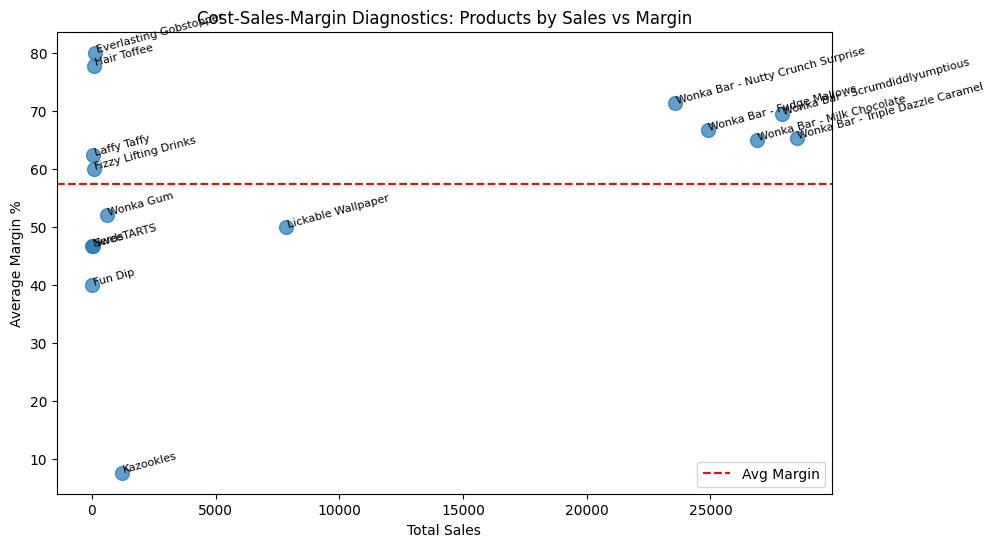

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(product_summary['Total_Sales'], product_summary['Avg_Margin'], s=100, alpha=0.7)

for i, row in product_summary.iterrows():
    plt.annotate(row['Product Name'], (row['Total_Sales'], row['Avg_Margin']), fontsize=8, rotation=15)

plt.xlabel('Total Sales')
plt.ylabel('Average Margin %')
plt.title('Cost-Sales-Margin Diagnostics: Products by Sales vs Margin')
plt.axhline(y=product_summary['Avg_Margin'].mean(), color='red', linestyle='--', label='Avg Margin')
plt.legend()
plt.show()

In [ ]:
df.to_csv('nassau_candy_cleaned.csv', index=False)

from google.colab import files
files.download('nassau_candy_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
df = pd.read_csv("nassau_candy_cleaned.csv")

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
monthly = df.groupby(['Product Name', df['Order Date'].dt.to_period('M')]).agg(
    S=('Sales', 'sum'), P=('Gross Profit', 'sum')
).reset_index()
monthly['Monthly_Margin'] = monthly['P'] / monthly['S'] * 100

volatility = monthly.groupby('Product Name')['Monthly_Margin'].agg(['std', 'count']).reset_index()
volatility.columns = ['Product Name', 'Margin_Volatility', 'Months_Active']
volatility = volatility.sort_values('Margin_Volatility', ascending=False)
volatility

,Product Name,Margin_Volatility,Months_Active
9,Wonka Bar - Fudge Mallows,1.108716e-14,24
10,Wonka Bar - Milk Chocolate,9.827717e-15,24
12,Wonka Bar - Scrumdiddlyumptious,7.258250e-15,24
13,Wonka Bar - Triple Dazzle Caramel,2.963168e-15,24
14,Wonka Gum,2.095276e-15,24
1,Fizzy Lifting Drinks,0.000000e+00,5
0,Everlasting Gobstopper,0.000000e+00,3
6,Lickable Wallpaper,0.000000e+00,20
5,Laffy Taffy,0.000000e+00,7
4,Kazookles,0.000000e+00,23


In [9]:
rev = product_summary.sort_values('Total_Sales', ascending=False).reset_index(drop=True)
rev['Cumulative_Revenue_%'] = rev['Total_Sales'].cumsum() / rev['Total_Sales'].sum() * 100
rev['Product_Rank_%'] = (rev.index + 1) / len(rev) * 100
rev[['Product Name', 'Total_Sales', 'Cumulative_Revenue_%', 'Product_Rank_%']]

,Product Name,Total_Sales,Cumulative_Revenue_%,Product_Rank_%
0,Wonka Bar - Triple Dazzle Caramel,28485.00,20.090472,6.666667
1,Wonka Bar - Scrumdiddlyumptious,27874.80,39.750569,13.333333
2,Wonka Bar - Milk Chocolate,26867.75,58.700394,20.000000
3,Wonka Bar - Fudge Mallows,24890.40,76.255595,26.666667
4,Wonka Bar - Nutty Crunch Surprise,23574.95,92.883008,33.333333
5,Lickable Wallpaper,7860.00,98.426666,40.000000
6,Kazookles,1205.75,99.277082,46.666667
7,Wonka Gum,597.50,99.698498,53.333333
8,Everlasting Gobstopper,130.00,99.790187,60.000000
9,Fizzy Lifting Drinks,78.75,99.845730,66.666667


In [10]:
kpi = product_summary.copy()
kpi['Revenue_Contribution_%'] = kpi['Total_Sales'] / kpi['Total_Sales'].sum() * 100
kpi['Profit_Contribution_%'] = kpi['Total_Profit'] / kpi['Total_Profit'].sum() * 100
kpi['Profit_per_Unit'] = kpi['Total_Profit'] / kpi['Total_Units']
kpi[['Product Name', 'Revenue_Contribution_%', 'Profit_Contribution_%', 'Profit_per_Unit']].round(2)

,Product Name,Revenue_Contribution_%,Profit_Contribution_%,Profit_per_Unit
12,Wonka Bar - Scrumdiddlyumptious,19.66,20.72,2.50
13,Wonka Bar - Triple Dazzle Caramel,20.09,19.92,2.45
10,Wonka Bar - Milk Chocolate,18.95,18.67,2.11
11,Wonka Bar - Nutty Crunch Surprise,16.63,18.00,2.49
9,Wonka Bar - Fudge Mallows,17.56,17.76,2.40
6,Lickable Wallpaper,5.54,4.21,10.00
14,Wonka Gum,0.42,0.33,0.65
0,Everlasting Gobstopper,0.09,0.11,8.00
4,Kazookles,0.85,0.10,0.25
3,Hair Toffee,0.05,0.06,3.50
